In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Full test shape: (199, 92)
Full test class ratio:
is_successful
1    0.733668
0    0.266332
Name: proportion, dtype: float64

Evaluation sample shape: (199, 92)
Evaluation sample class ratio:
is_successful
1    0.733668
0    0.266332
Name: proportion, dtype: float64

All models loaded.
Logistic Regression prediction done.
Random Forest prediction done.
XGBoost prediction done.


,model,sample_size,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1,true_negative,false_positive,false_negative,true_positive
0,Logistic Regression,199,0.5,0.743603,0.873717,0.788945,0.833333,0.890411,0.860927,27,26,16,130
1,Random Forest,199,0.5,0.791161,0.898830,0.798995,0.808140,0.952055,0.874214,20,33,7,139
2,XGBoost,199,0.5,0.761049,0.889710,0.809045,0.817647,0.952055,0.879747,22,31,7,139



Logistic Regression
              precision    recall  f1-score   support

           0       0.63      0.51      0.56        53
           1       0.83      0.89      0.86       146

    accuracy                           0.79       199
   macro avg       0.73      0.70      0.71       199
weighted avg       0.78      0.79      0.78       199


Random Forest
              precision    recall  f1-score   support

           0       0.74      0.38      0.50        53
           1       0.81      0.95      0.87       146

    accuracy                           0.80       199
   macro avg       0.77      0.66      0.69       199
weighted avg       0.79      0.80      0.77       199


XGBoost
              precision    recall  f1-score   support

           0       0.76      0.42      0.54        53
           1       0.82      0.95      0.88       146

    accuracy                           0.81       199
   macro avg       0.79      0.68      0.71       199
weighted avg       0.80      

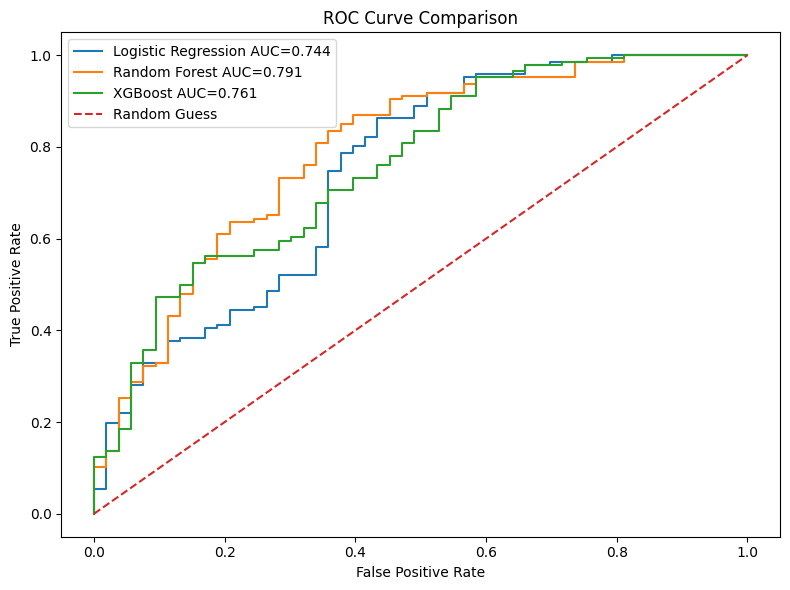

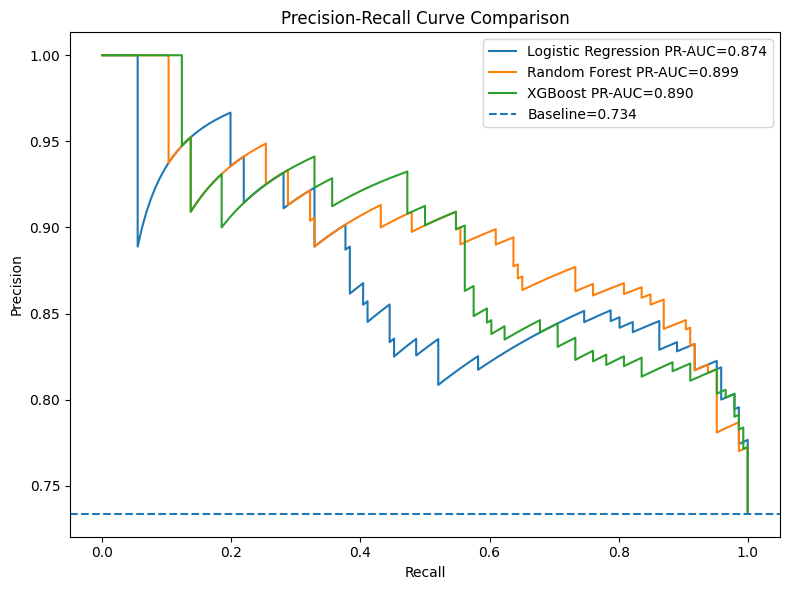

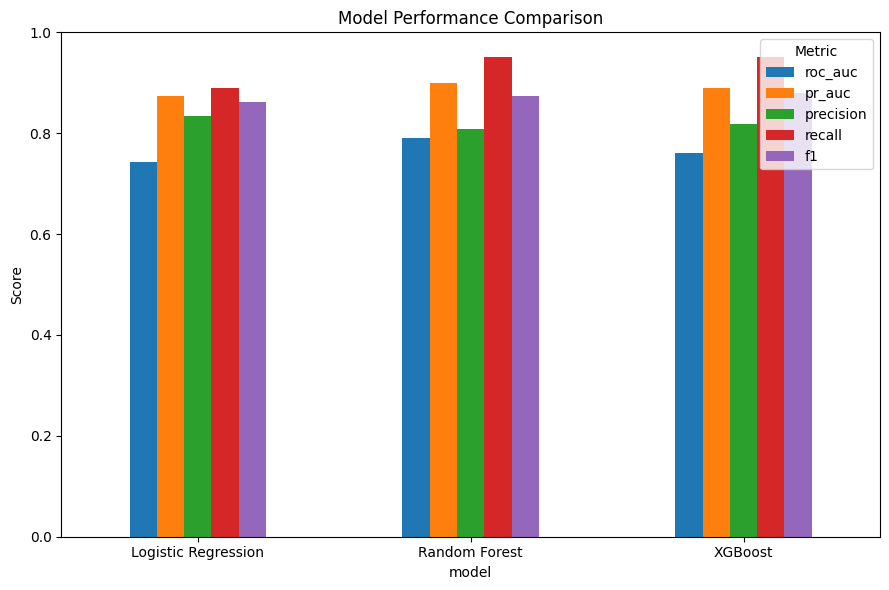


Evaluation completed.
Outputs saved to: /content/drive/MyDrive/Colab Notebooks/outputs/evaluation


In [8]:
# ============================================================
# Fast Evaluation Pipeline for Saved Models
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

from pathlib import Path

project_root = Path("/content/drive/MyDrive/Colab Notebooks")

paths = {
    "features": project_root / "data" / "processed" / "features.csv",
    "target": project_root / "data" / "processed" / "target.csv",
    "split_appids": project_root / "outputs" / "modeling" / "split_appids.csv",

    "logreg_model": project_root / "models" / "logistic_regression_best.joblib",
    "rf_model": project_root / "models" / "random_forest_best.joblib",
    "xgb_model": project_root / "models" / "xgboost_best.joblib",

    "evaluation_dir": project_root / "outputs" / "evaluation"
}

paths["evaluation_dir"].mkdir(parents=True, exist_ok=True)

# ============================================================
# 2. Load Data
# ============================================================

features = pd.read_csv(paths["features"])
target = pd.read_csv(paths["target"])

df = features.merge(target, on="appid", how="inner")

y = df["is_successful"].astype(int)
X = df.drop(columns=["appid", "is_successful"])

split_appids = pd.read_csv(paths["split_appids"])

test_appids = split_appids.loc[
    split_appids["split"] == "test",
    "appid"
]

mask = df["appid"].isin(test_appids)

X_test = X.loc[mask]
y_test = y.loc[mask]

print("Full test shape:", X_test.shape)
print("Full test class ratio:")
print(y_test.value_counts(normalize=True))


# ============================================================
# 3. Use Small Evaluation Sample
# ============================================================

SAMPLE_SIZE = min(1000, len(X_test))

X_eval = X_test.sample(n=SAMPLE_SIZE, random_state=42)
y_eval = y_test.loc[X_eval.index]

# reduce memory
X_eval = X_eval.astype("float32")

print("\nEvaluation sample shape:", X_eval.shape)
print("Evaluation sample class ratio:")
print(y_eval.value_counts(normalize=True))


# ============================================================
# 4. Load Models Only Once
# ============================================================

logreg_model = joblib.load(paths["logreg_model"])
rf_model = joblib.load(paths["rf_model"])
xgb_model = joblib.load(paths["xgb_model"])

print("\nAll models loaded.")


# ============================================================
# 5. Predict Only Once
# ============================================================

y_prob_lr = logreg_model.predict_proba(X_eval)[:, 1]
print("Logistic Regression prediction done.")

y_prob_rf = rf_model.predict_proba(X_eval)[:, 1]
print("Random Forest prediction done.")

y_prob_xgb = xgb_model.predict_proba(X_eval)[:, 1]
print("XGBoost prediction done.")


prediction_results = {
    "Logistic Regression": y_prob_lr,
    "Random Forest": y_prob_rf,
    "XGBoost": y_prob_xgb
}


# ============================================================
# 6. Metrics Table
# ============================================================

metrics_rows = []

for model_name, y_prob in prediction_results.items():
    y_pred = (y_prob >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

    metrics_rows.append({
        "model": model_name,
        "sample_size": SAMPLE_SIZE,
        "threshold": 0.5,
        "roc_auc": roc_auc_score(y_eval, y_prob),
        "pr_auc": average_precision_score(y_eval, y_prob),
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

metrics_df = pd.DataFrame(metrics_rows)

display(metrics_df)

metrics_df.to_csv(
    paths["evaluation_dir"] / "fast_sample_metrics.csv",
    index=False
)


# ============================================================
# 7. Classification Reports
# ============================================================

for model_name, y_prob in prediction_results.items():
    y_pred = (y_prob >= 0.5).astype(int)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_eval, y_pred, zero_division=0))


# ============================================================
# 8. ROC Curve
# ============================================================

plt.figure(figsize=(8, 6))

for model_name, y_prob in prediction_results.items():
    fpr, tpr, _ = roc_curve(y_eval, y_prob)
    auc = roc_auc_score(y_eval, y_prob)

    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc:.3f}")

plt.plot([0, 1], [0, 1], "--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(paths["evaluation_dir"] / "fast_sample_roc_curve.png", dpi=300)
plt.show()


# ============================================================
# 9. Precision-Recall Curve
# ============================================================

plt.figure(figsize=(8, 6))

baseline = y_eval.mean()

for model_name, y_prob in prediction_results.items():
    precision, recall, _ = precision_recall_curve(y_eval, y_prob)
    pr_auc = average_precision_score(y_eval, y_prob)

    plt.plot(recall, precision, label=f"{model_name} PR-AUC={pr_auc:.3f}")

plt.axhline(y=baseline, linestyle="--", label=f"Baseline={baseline:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(paths["evaluation_dir"] / "fast_sample_pr_curve.png", dpi=300)
plt.show()


# ============================================================
# 10. Bar Chart
# ============================================================

plot_df = metrics_df.set_index("model")[
    ["roc_auc", "pr_auc", "precision", "recall", "f1"]
]

plot_df.plot(kind="bar", figsize=(9, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(paths["evaluation_dir"] / "fast_sample_metrics_bar_chart.png", dpi=300)
plt.show()


# ============================================================
# 11. Save Prediction Probabilities
# ============================================================

prob_df = pd.DataFrame({
    "appid": df.loc[X_eval.index, "appid"].values,
    "y_true": y_eval.values,
    "logistic_regression_prob": y_prob_lr,
    "random_forest_prob": y_prob_rf,
    "xgboost_prob": y_prob_xgb
})

prob_df.to_csv(
    paths["evaluation_dir"] / "fast_sample_prediction_probabilities.csv",
    index=False
)

print("\nEvaluation completed.")
print("Outputs saved to:", paths["evaluation_dir"])

In [6]:
from pathlib import Path

for p in Path("/content/drive/MyDrive").rglob("features.csv"):
    print(p)

/content/drive/MyDrive/Colab Notebooks/data/processed/features.csv
